In [1]:
from spin_lattices import SpinLattice, KagomeLattice, SquareLattice, TriangularLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
import numpy as np
import numpy.typing as npt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from misc_utils import hadamard_transform_pytorch_inplace
import torch
import unittest
from tqdm.auto import tqdm
from fourier_supervised_cleanroom_2023_09_27 import get_lattice
from nn_supervised_reproduction import get_config, output_dir, default_config, SignDenseNetXor
from misc_utils import read_jsonl_to_df, keep_serializable, column_to, concat_columns
from parity import parity
from scipy.special import comb

In [5]:
df = (
    read_jsonl_to_df(output_dir.glob("*/results.jsonl"))
    .fillna(keep_serializable(default_config))
    # .assign(
    #     full_arch=concat_columns(
    #         ["architecture", "xor_strategy", "n_xors", "xor_hamming_weight", "xor_sampling_power"]
    #     )
    # )
)

In [3]:
df['dilations'].astype(str).unique()

array(['nan', '[1, 2, 3]', '[3, 2, 1, 1]', '[3, 2, 1]', '[1, 1, 2, 3]',
       '[2, 2, 2]', '[1, 2, 3, 3]', '[3, 3, 2, 1]', '[2, 2, 2, 2]'],
      dtype=object)

In [7]:
df['architecture'].unique()

array(['invariant_cnn'], dtype=object)

In [18]:
df.query('architecture == "invariant_cnn" and eps_train == 0.05')

,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,batch_size,shuffle,...,runs,run,J2s,dilations,use_symmetries,skip_symmetries_whitelist,hidden_channels,task_id,xor_sampling_power,full_arch
44900,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
44901,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
44902,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
44903,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
44904,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570079,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570080,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570081,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570082,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan


In [26]:
df.query("architecture == 'invariant_cnn'")

,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,batch_size,shuffle,...,runs,run,J2s,dilations,use_symmetries,skip_symmetries_whitelist,hidden_channels,task_id,xor_sampling_power,full_arch
42900,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
42901,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
42902,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
42903,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
42904,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,0.0,[0.5],"[1, 2, 3]",True,False,"[32, 32, 32]",42.0,NaN,invariant_cnn_nan_nan_nan_nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1570699,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570700,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570701,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan
1570702,5000,2.0,invariant_cnn,512,1,200,1,0.001,64,True,...,10.0,9.0,[0.5],"[3, 2, 1]",True,False,"[32, 32, 32]",43.0,NaN,invariant_cnn_nan_nan_nan_nan


In [5]:
df.query('architecture == "invariant_cnn" and eps_train == 0.05')['lattice'].unique()

array(['square6x6', 'square6x4', 'triangular6x4'], dtype=object)

In [6]:
df.query(
        'task_id in [55, 56]'
    )['run'].max()

0.0

In [13]:
df.query(
        'task_id in [55, 56]'
    ).groupby(['eps_train', 'task_id'])['n_train'].mean()

eps_train  task_id
0.01       55.0        27041.0
           56.0        27041.0
0.05       55.0       135207.0
           56.0       135207.0
Name: n_train, dtype: float64

In [25]:
df.query(
        'task_id in [55, 56] and eps_train == 0.01 and epoch < 200'
    ).groupby('task_id')['n_train'].mean()

task_id
55.0    27041.0
56.0    27041.0
Name: n_train, dtype: float64

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


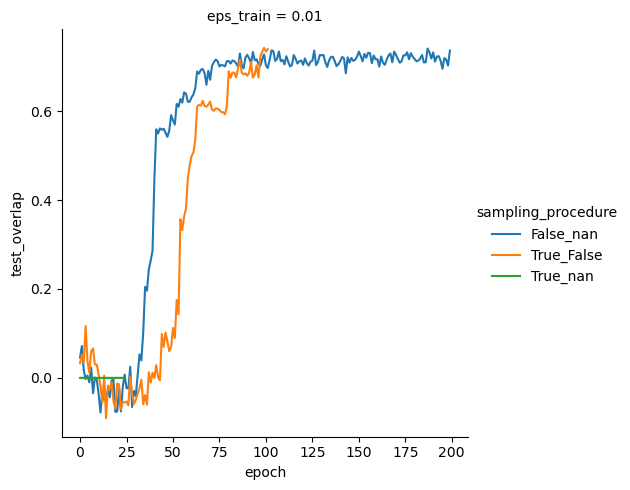

In [51]:
sns.relplot(
    df.query("lattice == 'square6x6' and architecture == 'dense'")
    .pipe(column_to(str, "task_id"))
    .assign(
        mean_train_loss=lambda df: df["train_loss"] / df["n_train"],
        sampling_procedure=concat_columns(
            ["sample_repr_then_apply_random_symmetry", "n_train_from_full_space"]
        ),
    ),
    x="epoch",
    y="test_overlap",
    hue="sampling_procedure",
    col="eps_train",
    kind="line",
)

In [14]:
df.query(
        'architecture == "invariant_cnn" and  lattice == "square6x6" and not n_train_from_full_space and start_timestamp >= "20231107_145846.412838"'
    )

,J2s,eps_train,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,...,task_id,sample_repr_then_apply_random_symmetry,sample_with_replacement,hadamard_basis,n_train_from_full_space,n_train,n_xors,xor_strategy,xor_hamming_weight,xor_sampling_power
1130052,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130053,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130054,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130055,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130056,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130057,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130058,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130059,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130060,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN
1130061,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,59.0,True,True,False,False,31566.0,NaN,NaN,NaN,NaN


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


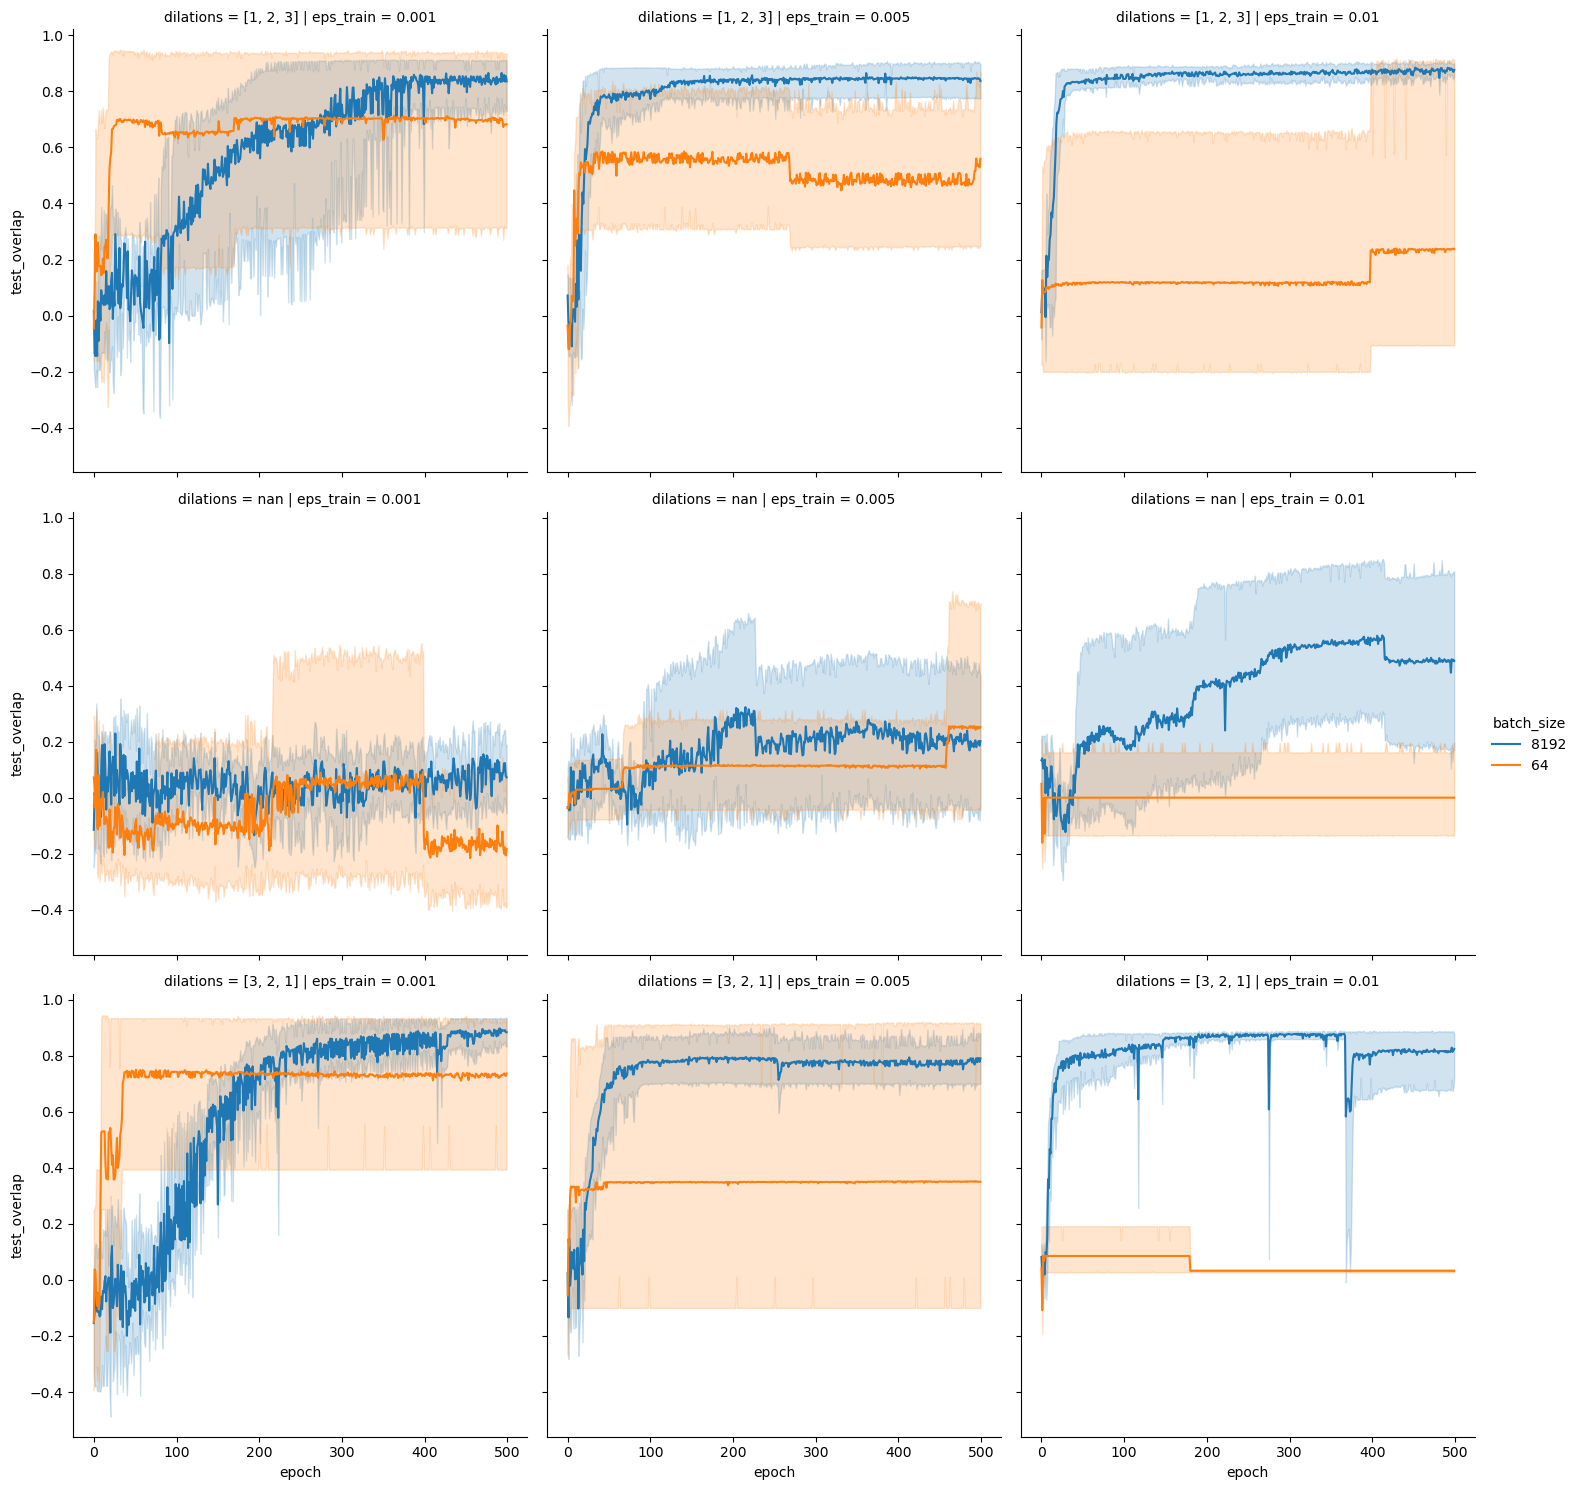

In [8]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" '
        'and  lattice == "square6x6" '
        "and not n_train_from_full_space "
        # 'and epoch < 100 '
        "and not last_layer_bias "
        # 'and batch_size == 8192'
    ).pipe(column_to(str, ["dilations", "task_id", "batch_size"])),
    x="epoch",
    y="test_overlap",
    hue="batch_size",
    row="dilations",
    col="eps_train",
    #style="run",
    kind="line",
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


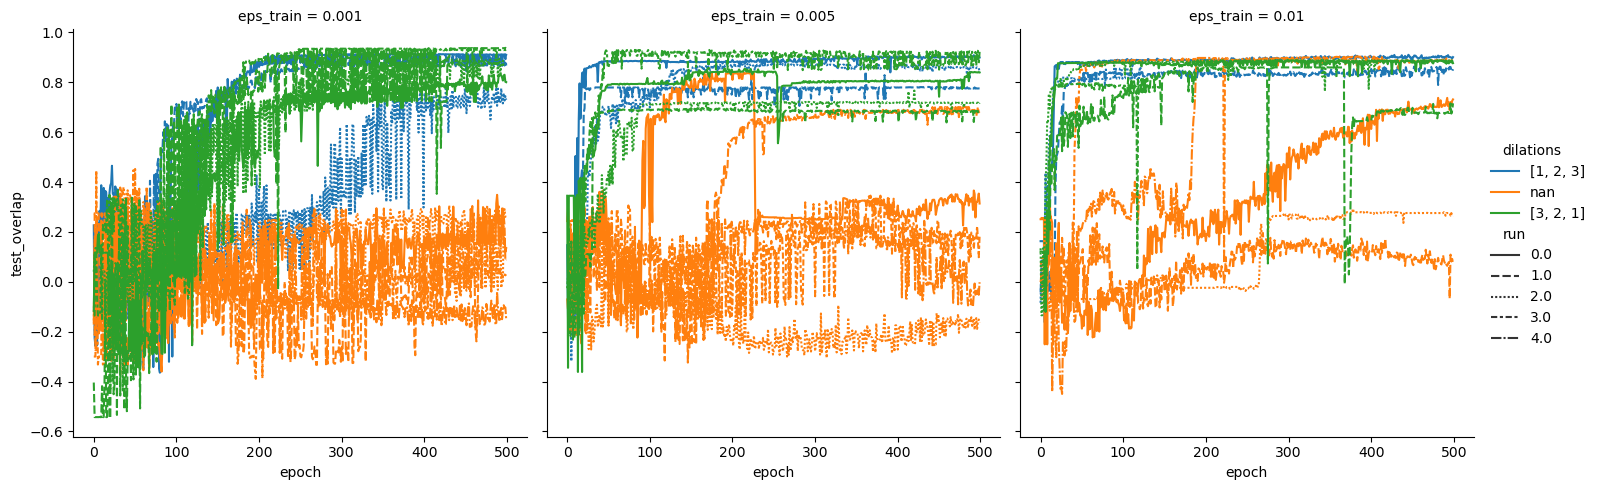

In [6]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" '
        'and  lattice == "square6x6" '
        'and not n_train_from_full_space '
       # 'and epoch < 100 '
        'and not last_layer_bias '
        'and batch_size == 8192'
    ).pipe(column_to(str, ["dilations", "task_id"])),
    x="epoch",
    y="test_overlap",
    hue="dilations",
    col='eps_train',
    style='run',
    kind="line",
)

In [7]:
df.query(
        'architecture == "invariant_cnn" '
        'and lattice == "triangular6x6" '
        'and not n_train_from_full_space '
       # 'and epoch < 100 '
        'and not last_layer_bias '
        'and batch_size == 8192 '
    )['J2'].unique()

array([1.3])

In [7]:
df.query(
    'architecture == "invariant_cnn" '
    'and lattice == "triangular6x6" '
    "and not n_train_from_full_space "
    # 'and epoch < 100 '
    "and not last_layer_bias "
    "and batch_size == 8192 "
)["task_id"].value_counts()

task_id
72.0    13890
71.0     4239
80.0     2508
76.0     2500
75.0     2500
77.0     2500
79.0     2500
73.0     2500
74.0     2196
70.0      756
Name: count, dtype: int64

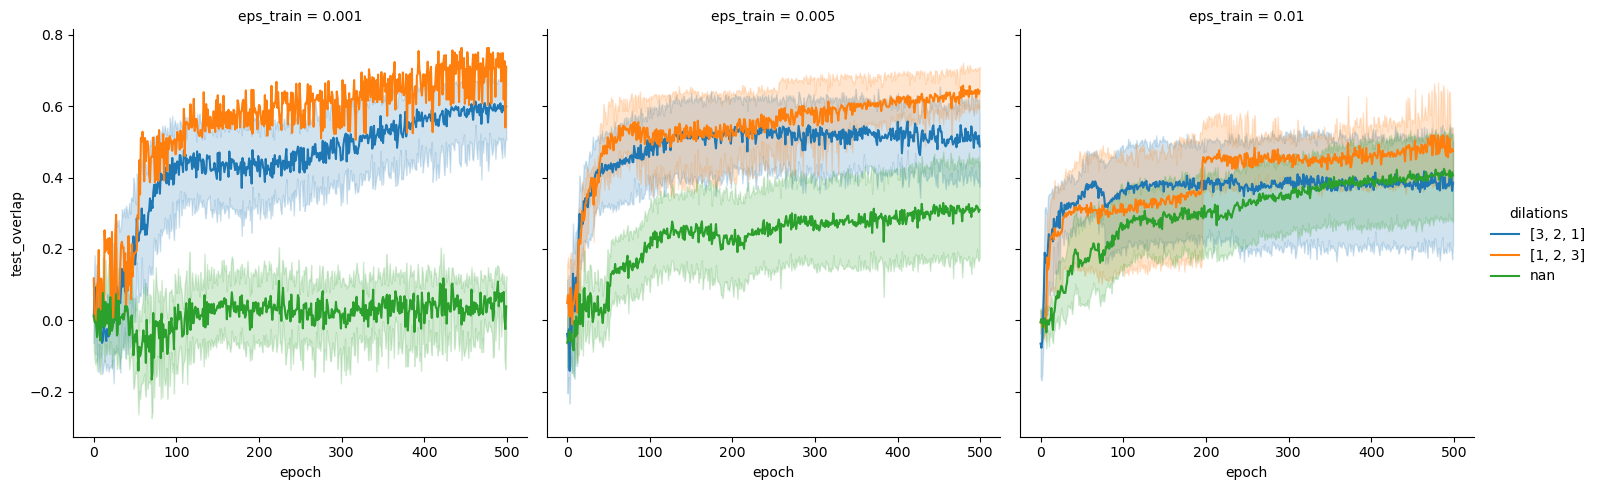

In [4]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" '
        'and lattice == "triangular6x6" '
        'and not n_train_from_full_space '
       # 'and epoch < 100 '
        'and not last_layer_bias '
        'and batch_size == 8192 '
    ).pipe(column_to(str, ["dilations", "task_id"])),
    x="epoch",
    y="test_overlap",
    hue="dilations",
    col='eps_train',
    #style='run',
    kind="line",
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


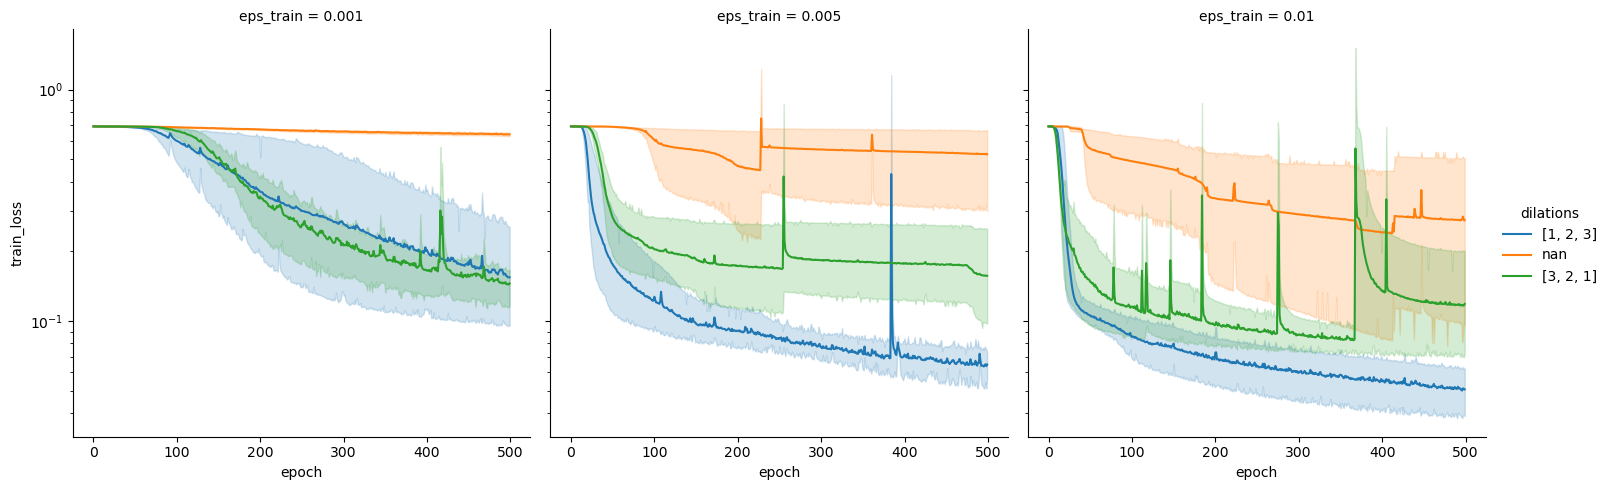

In [11]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" '
        'and  lattice == "square6x6" '
        'and not n_train_from_full_space '
       # 'and epoch < 100 '
        'and not last_layer_bias '
        'and batch_size == 8192 '
    ).pipe(column_to(str, ["dilations", "task_id"])),
    x="epoch",
    y="train_loss",
    hue="dilations",
    col='eps_train',
    #style='run',
    kind="line",
).set(yscale='log')

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


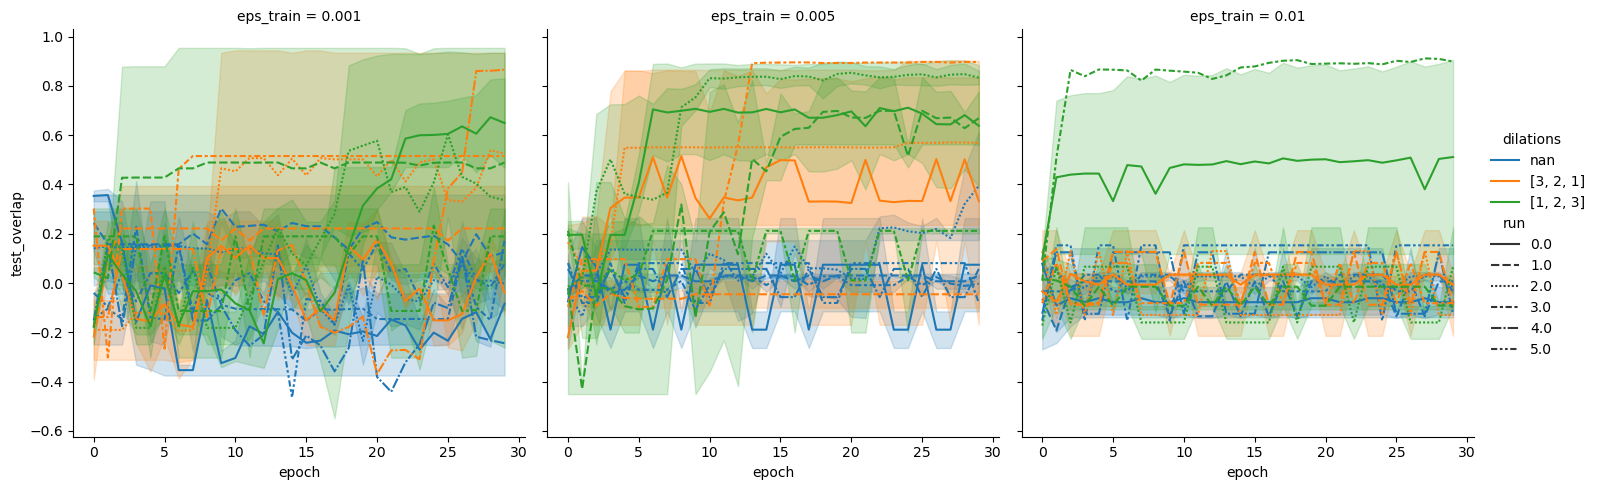

In [4]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" '
        'and  lattice == "square6x6" '
        'and not n_train_from_full_space '
        'and start_timestamp >= "20231107_14" '
        'and epoch < 30'
    ).pipe(column_to(str, ["dilations", "task_id"])),
    x="epoch",
    y="test_overlap",
    hue="dilations",
    col='eps_train',
    style='run',
    kind="line",
)

In [45]:
epoch = 21
prediction = np.load(output_dir / "58" / f"prediction_0_0.5_0.001_{epoch}.npy")
prediction.argmax(axis=1).mean()

0.0

In [16]:
df.columns

Index(['J2s', 'eps_train', 'n_test', 'sampling_power_train', 'architecture',
       'n_hidden', 'hidden_layers', 'epochs', 'write_each_epoch', 'lr',
       'batch_size', 'shuffle', 'runs', 'use_symmetries',
       'skip_symmetries_whitelist', 'sample_repr_then_apply_random_symmetry',
       'sample_with_replacement', 'hadamard_basis', 'n_train_from_full_space',
       'one_dimensonal_output', 'last_layer_bias', 'lattice',
       'hidden_channels', 'kernel_size', 'write_each', 'test_overlap',
       'test_accuracy', 'train_loss', 'epoch', 'J2', 'start_timestamp',
       'current_timestamp', 'run', 'task_id', 'n_train', 'dilations'],
      dtype='object')

In [17]:
df.query(
    'architecture == "invariant_cnn"'
    ' and eps_train == 0.001 and lattice == "triangular6x6"'
).assign(n_layers=lambda df: df["hidden_channels"].apply(len)).query(
    "n_layers == 4"
).pipe(
    column_to(str, "dilations")
).groupby(
    ["dilations", "epoch"]
).size().sort_values()

dilations     epoch
nan           468      10
              469      10
              470      10
              471      10
              472      10
                       ..
              496      10
              497      10
              498      10
              499      10
[1, 1, 2, 3]  0        10
Length: 3000, dtype: int64

In [36]:
(df.query(
        'architecture == "invariant_cnn" and eps_train == 0.001 and lattice == "triangular6x6"'
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .query("n_layers == 4")
    .pipe(column_to(str, "dilations")).groupby(["dilations", "epoch"]).size().sort_values())

dilations     epoch
nan           468      10
              469      10
              470      10
              471      10
              472      10
                       ..
              496      10
              497      10
              498      10
              499      10
[1, 1, 2, 3]  0        10
Length: 3000, dtype: int64

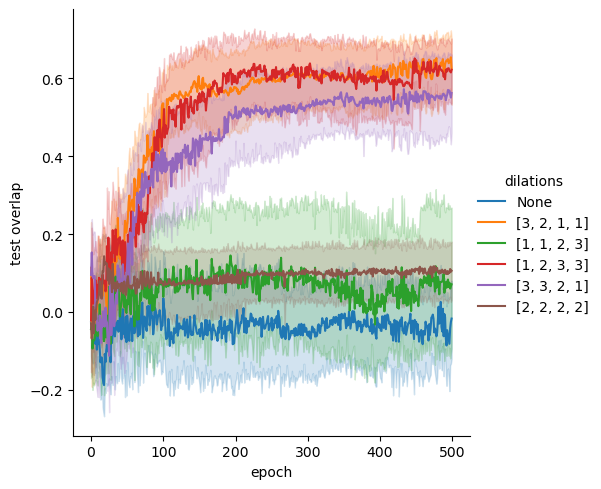

In [25]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" and eps_train == 0.001 and lattice == "triangular6x6"'
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .query("n_layers == 4")
    .fillna({"dilations": "None"})
    .pipe(column_to(str, "dilations"))
    .rename(columns={"test_overlap": "test overlap"}),
    x="epoch",
    y="test overlap",
    hue="dilations",
    kind="line",
)
plt.savefig("fig/dilations/nn_supervised_reproduction_dilations_triangular6x6.pdf")

In [36]:
(
    df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 3"
        " and task_id not in [72, 81]"  # some duplicating tasks to remove
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .query("n_layers >= 3")
    .pipe(column_to(str, "dilations"))
    .groupby(["epoch", "dilations", "eps_train", "n_layers"])
    .size()
    .sort_values()
)

epoch  dilations     eps_train  n_layers
498    nan           0.010      3           10
                                4           10
499    [1, 1, 2, 3]  0.001      4           10
                     0.005      4           10
                     0.010      4           10
                                            ..
       nan           0.005      3           10
                                4           10
                     0.010      3           10
                                4           10
0      [1, 1, 2, 3]  0.001      4           10
Length: 15000, dtype: int64

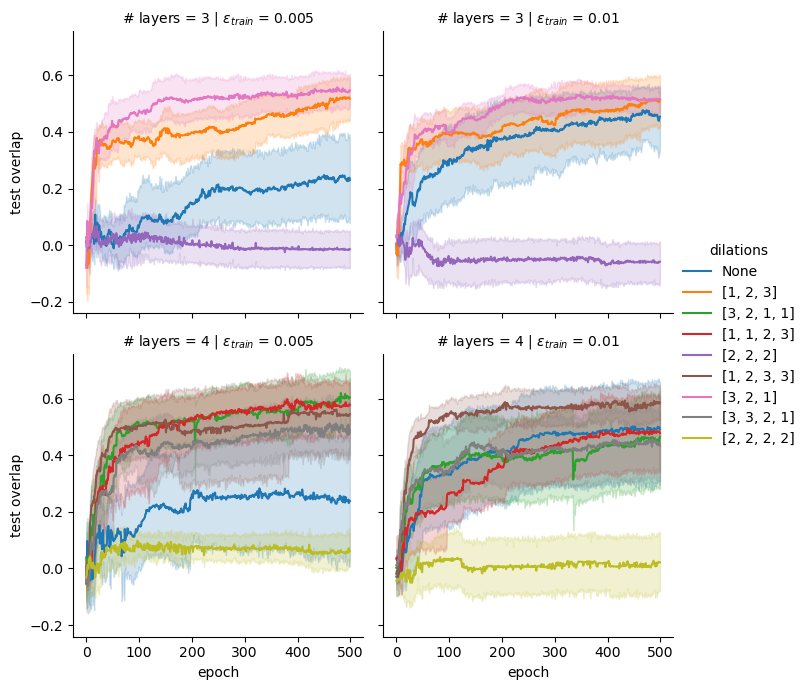

In [31]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        ' and kernel_size == 3'
        " and task_id not in [72, 81]" # some duplicating tasks to remove
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .query('n_layers >= 3')
    .query('eps_train > 0.0011')
    .fillna({"dilations": "None"})
    .pipe(column_to(str, "dilations"))
    .rename(columns={"test_overlap": "test overlap", "eps_train": r"$\varepsilon_{train}$", "n_layers": "# layers"}),
    x="epoch",
    y="test overlap",
    hue="dilations",
    kind="line",
    col=r"$\varepsilon_{train}$",
    row="# layers",
    height=3.5,
)
# same as original, various eps_train, various depths
plt.savefig("fig/dilations/nn_supervised_reproduction_dilations_triangular6x6_var.pdf")

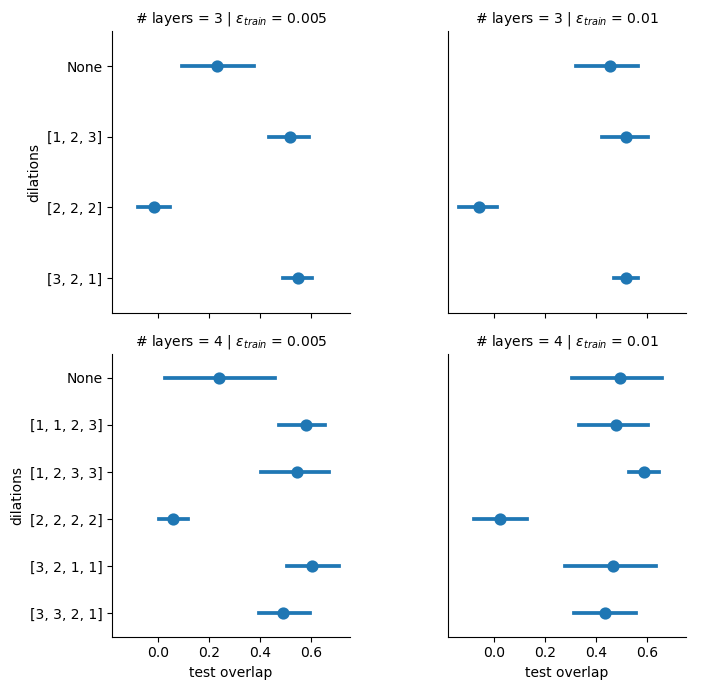

In [32]:
g = sns.catplot(
    df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 3"
        " and task_id not in [72, 81]"  # some duplicating tasks to remove
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .query("n_layers >= 3")
    .query('eps_train > 0.0011')
    .fillna({"dilations": "None"})
    .pipe(column_to(str, "dilations"))
    .query("epoch == 499")
    .sort_values("dilations")
    .rename(columns={"test_overlap": "test overlap", "eps_train": r"$\varepsilon_{train}$", "n_layers": "# layers"}),
    y="dilations",
    x="test overlap",
    # hue="dilations",  # Uncomment if you want to use dilations as hue
    linestyle="none",
    kind="point",
    col=r"$\varepsilon_{train}$",
    row="# layers",
    sharey=False,  # make y axes independent
    height=3.5,
)

# Iterate through the axes, removing y-ticks and labels for non-leftmost plots
for row in g.axes:
    for ax in row[1:]:
        ax.set_yticklabels([])
        ax.set_yticks([])

plt.savefig("fig/dilations/nn_supervised_reproduction_dilations_triangular6x6_var_confint.pdf")

In [ ]:
(df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 2"
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .pipe(column_to(str, "dilations")).groupby(['epoch', 'dilations', 'eps_train']).size().sort_values())

In [10]:
(
    df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 2"
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .pipe(column_to(str, "dilations"))
    .groupby(["epoch", "dilations", "eps_train"])
    .size()
    .sort_values()
)

epoch  dilations  eps_train
496    nan        0.010        10
497    [1, 2, 3]  0.001        10
                  0.005        10
                  0.010        10
       [3, 2, 1]  0.001        10
                               ..
499    [3, 2, 1]  0.010        10
       nan        0.001        10
                  0.005        10
                  0.010        10
0      [1, 2, 3]  0.001        10
Length: 4500, dtype: int64

In [24]:
(df.query(
        'architecture == "invariant_cnn"'
)['hidden_channels']).apply(np.array).apply(np.std).sort_values()

241880    0.0
241881    0.0
241882    0.0
241883    0.0
241884    0.0
         ... 
241911    0.0
241912    0.0
241913    0.0
241914    0.0
0         0.0
Name: hidden_channels, Length: 241915, dtype: float64

In [ ]:
(df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 2"
    )

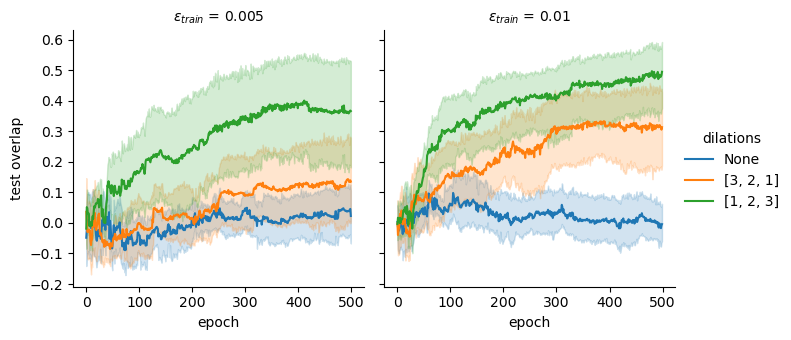

In [33]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" and lattice == "triangular6x6"'
        " and kernel_size == 2"
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .fillna({"dilations": "None"})
    .pipe(column_to(str, "dilations"))
    .query('eps_train > 0.0011')
    .rename(columns={"test_overlap": "test overlap", "eps_train": r"$\varepsilon_{train}$", "n_layers": "# layers"}),
    x="epoch",
    y="test overlap",
    hue="dilations",
    kind="line",
    col=r"$\varepsilon_{train}$",
    height=3.5,
)
plt.savefig("fig/dilations/nn_supervised_reproduction_dilations_triangular6x6_var_kernel2.pdf")
# kernel_size == 2, various eps_train

In [33]:
df.query('architecture == "invariant_cnn" and lattice == "square6x6"')

,J2s,eps_train,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,...,test_accuracy,train_loss,epoch,J2,start_timestamp,current_timestamp,run,task_id,n_train,dilations
90000,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5005,0.693309,0,0.5,20231206_195609.265541,20231206_195859.125252,0,58,31566,"[3, 2, 1]"
90001,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5005,0.693199,1,0.5,20231206_195609.265541,20231206_195900.645460,0,58,31566,"[3, 2, 1]"
90002,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5005,0.693182,2,0.5,20231206_195609.265541,20231206_195901.730550,0,58,31566,"[3, 2, 1]"
90003,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5005,0.693180,3,0.5,20231206_195609.265541,20231206_195902.811654,0,58,31566,"[3, 2, 1]"
90004,[0.5],0.001,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5005,0.693177,4,0.5,20231206_195609.265541,20231206_195903.891202,0,58,31566,"[3, 2, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134875,[0.5],0.005,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5008,0.087458,350,0.5,20231206_210821.922377,20231206_211057.618765,8,67,157830,"[3, 2, 1]"
134876,[0.5],0.005,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5009,0.087184,351,0.5,20231206_210821.922377,20231206_211057.854849,8,67,157830,"[3, 2, 1]"
134877,[0.5],0.005,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5012,0.087067,352,0.5,20231206_210821.922377,20231206_211058.090546,8,67,157830,"[3, 2, 1]"
134878,[0.5],0.005,10000,2.0,invariant_cnn,512,1,500,1,0.001,...,0.5010,0.087061,353,0.5,20231206_210821.922377,20231206_211058.328010,8,67,157830,"[3, 2, 1]"


In [29]:
(df.query(
        'architecture == "invariant_cnn" and lattice == "square6x6"'
    ).pipe(column_to(str, 'dilations'))[['eps_train', 'dilations', 'kernel_size']])

,eps_train,dilations,kernel_size
90000,0.001,"[3, 2, 1]",3
90001,0.001,"[3, 2, 1]",3
90002,0.001,"[3, 2, 1]",3
90003,0.001,"[3, 2, 1]",3
90004,0.001,"[3, 2, 1]",3
...,...,...,...
134875,0.005,"[3, 2, 1]",3
134876,0.005,"[3, 2, 1]",3
134877,0.005,"[3, 2, 1]",3
134878,0.005,"[3, 2, 1]",3


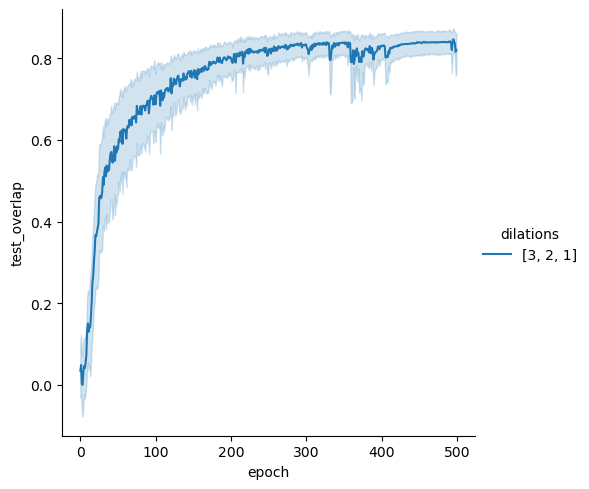

In [23]:
sns.relplot(
    df.query(
        'architecture == "invariant_cnn" and lattice == "square6x6"'
    )
    .assign(n_layers=lambda df: df["hidden_channels"].apply(len))
    .pipe(column_to(str, "dilations")),
    x="epoch",
    y="test_overlap",
    hue="dilations",
    kind="line",
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


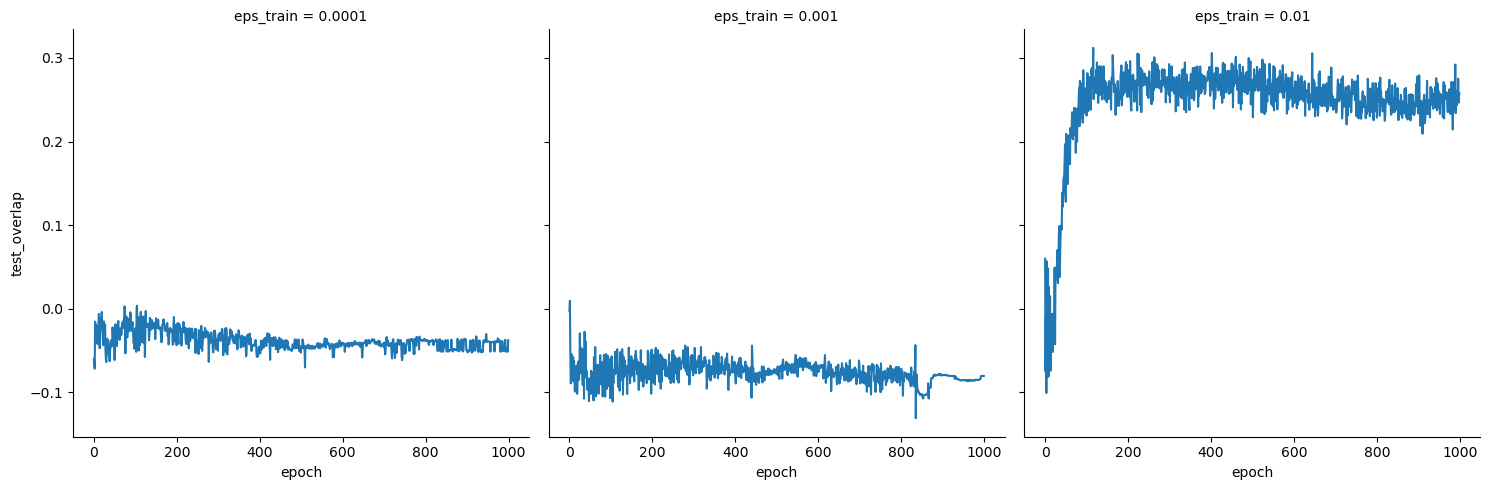

In [ ]:
sns.relplot(
    df.query('(lattice == "kagome2x4" and J2 == 1  and sampling_power_train == 2 )'),
    x='epoch',
    y='test_overlap', kind='line', col='eps_train')


/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


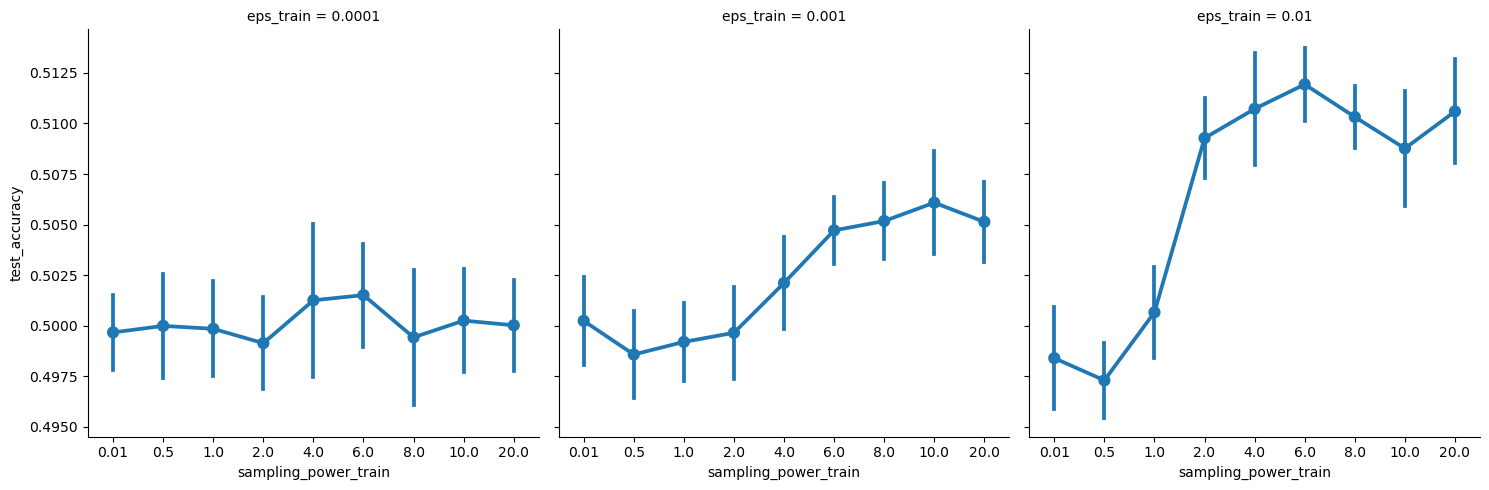

In [ ]:
sns.catplot(
    (
        df.query('(lattice == "kagome2x4" and J2 >= 0.8 and epoch >= 200)')
    ),
    x="sampling_power_train",
    y="test_accuracy",
    col="eps_train",
    kind='point',
    errorbar='sd',
)
#plt.savefig("fig/fourier_supervised_cleanroom-overlap-vs-sampling_power_train.pdf")

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


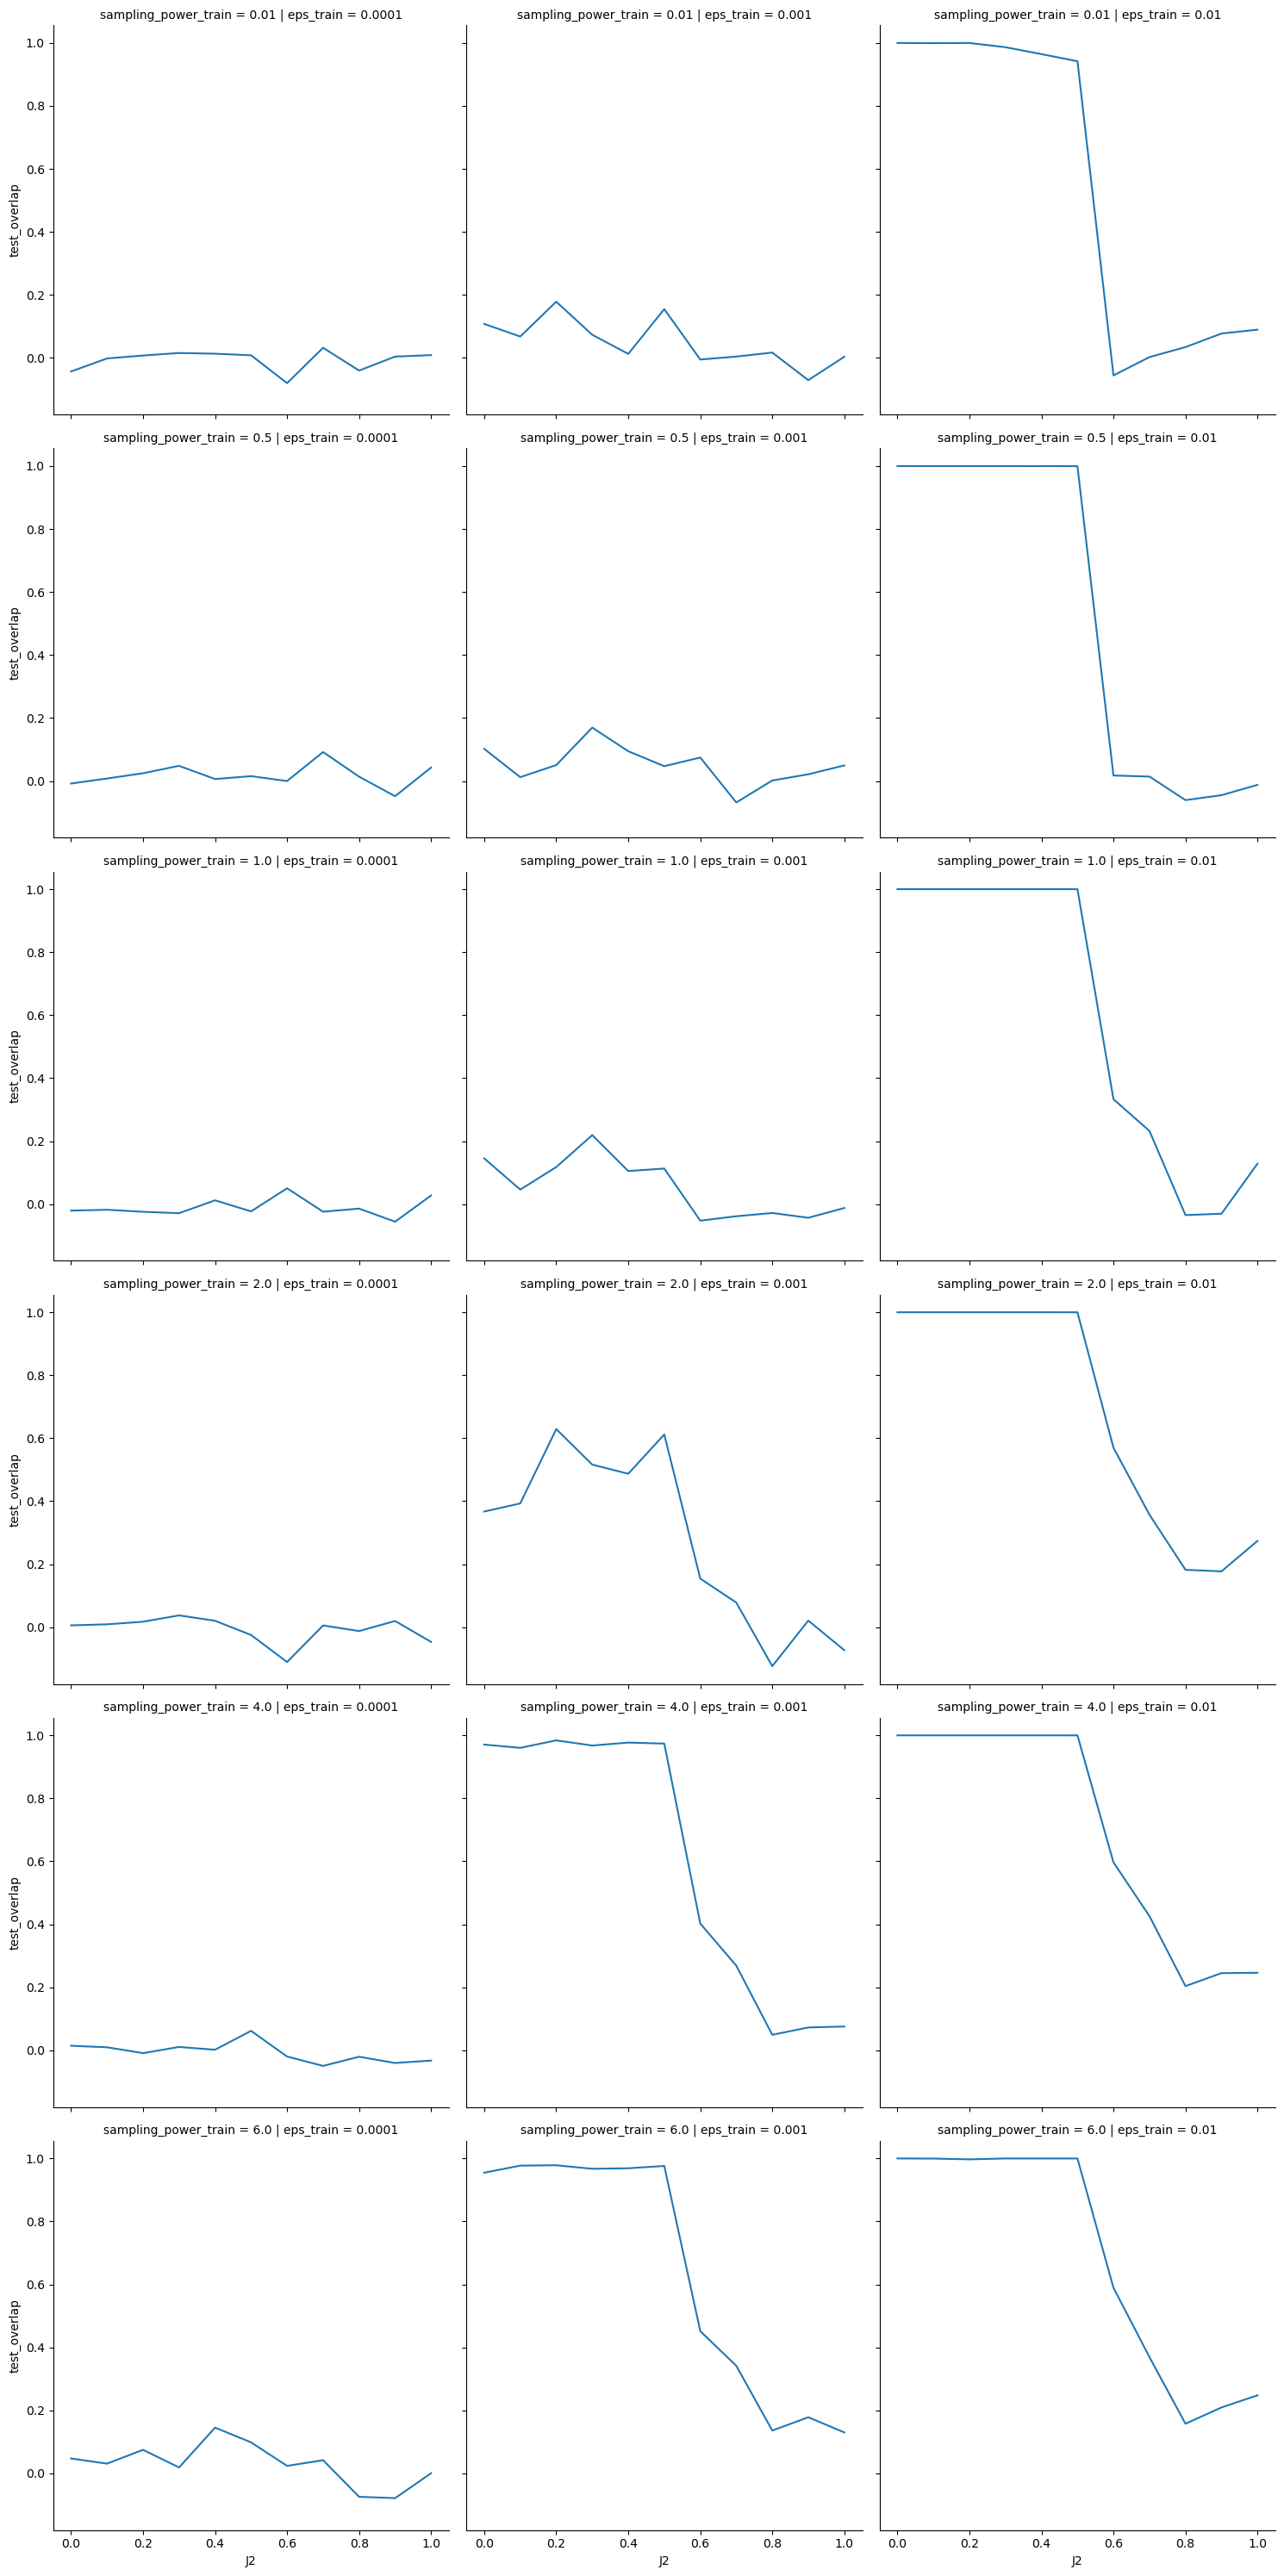

In [ ]:
sns.relplot(
    df.query('lattice == "kagome2x4" and epoch == 500'),
    x="J2",
    y="test_overlap",
    col='eps_train',
    kind='line',
    row='sampling_power_train',
)

In [15]:
# show all columns
pd.set_option('display.max_columns', None)

In [37]:
df.query(
    'lattice == "kagome2x4" '
    "and J2 == 1 "
    "and epoch == 299 "
    "and sampling_power_train == 2 "
    "and eps_train == 0.01 "
).groupby('full_arch')[['test_overlap', 'test_accuracy']].agg(['mean', 'std']).sort_values(('test_overlap', 'mean'))

test_overlap           test_accuracy  \
                                              mean       std          mean   
full_arch                                                                    
dense+xor_hamming_weight_8.0_2.0_nan      0.125488  0.034069      0.505260   
dense+xor_hamming_weight_4.0_2.0_nan      0.195763  0.021026      0.507698   
dense+xor_hamming_weight_1.0_2.0_nan      0.215771  0.035868      0.510060   
dense+xor_hamming_weight_2.0_2.0_nan      0.230758  0.022591      0.509044   
dense_nan_nan_nan_nan                     0.260210  0.034091      0.506800   
dense+xor_hamming_weight_1.0_12.0_nan     0.407443  0.100511      0.518776   
dense+xor_uniform_1.0_nan_nan             0.445118  0.134693      0.520420   
dense+xor_uniform_2.0_nan_nan             0.446269  0.096828      0.522218   
dense+xor_fourier_weight_1.0_nan_2.0      0.447176  0.146183      0.521460   
dense+xor_hamming_weight_8.0_12.0_nan     0.473768  0.061130      0.522092   
dense+xor_uniform_4.0_nan_nan             0.475128  0.054192      0.522700   
dense+xor_uniform_8.0_nan_nan             0.487356  0.061451      0.523672   
dense+xor_hamming_weight_2.0_12.0_nan     0.516482  0.095312      0.526266   
dense+xor_hamming_weight_4.0_12.0_nan     0.518587  0.050486      0.526836   
dense+xor_fourier_weight_2.0_nan_2.0      0.559124  0.095102      0.531300   
dense+xor_fourier_weight_8.0_nan_2.0      0.575952  0.059532      0.531200   
dense+xor_fourier_weight_4.0_nan_2.0      0.601630  0.024773      0.531878   

                                                 
                                            std  
full_arch                                        
dense+xor_hamming_weight_8.0_2.0_nan   0.001852  
dense+xor_hamming_weight_4.0_2.0_nan   0.002319  
dense+xor_hamming_weight_1.0_2.0_nan   0.002325  
dense+xor_hamming_weight_2.0_2.0_nan   0.002591  
dense_nan_nan_nan_nan                  0.000970  
dense+xor_hamming_weight_1.0_12.0_nan  0.007044  
dense+xor_uniform_1.0_nan_nan          0.009058  
dense+xor_uniform_2.0_nan_nan          0.005790  
dense+xor_fourier_weight_1.0_nan_2.0   0.009740  
dense+xor_hamming_weight_8.0_12.0_nan  0.004244  
dense+xor_uniform_4.0_nan_nan          0.003499  
dense+xor_uniform_8.0_nan_nan          0.004814  
dense+xor_hamming_weight_2.0_12.0_nan  0.006977  
dense+xor_hamming_weight_4.0_12.0_nan  0.003975  
dense+xor_fourier_weight_2.0_nan_2.0   0.008507  
dense+xor_fourier_weight_8.0_nan_2.0   0.004410  
dense+xor_fourier_weight_4.0_nan_2.0   0.004104

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


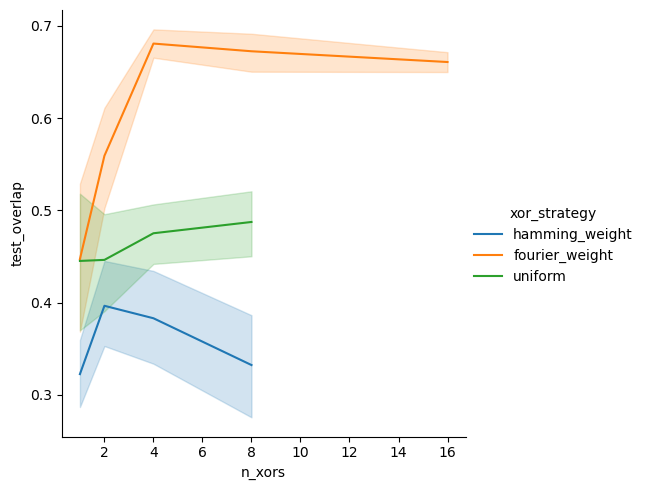

In [63]:
sns.relplot(df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"   
    ),
    x='n_xors',
    y='test_overlap',
    kind='line',
    hue='xor_strategy',
)

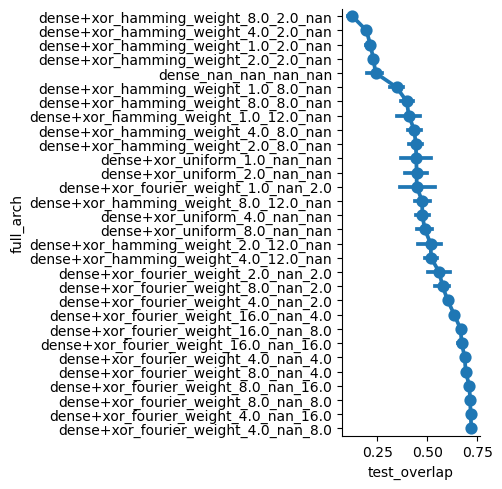

In [9]:
sns.catplot(
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
       
    ).pipe(column_to(str, "eps_train")),
    y="full_arch",
    x="test_overlap",
    kind="point",
    order=list(
        df.query(
            'lattice == "kagome2x4" '
            "and J2 == 1 "
            "and epoch == 299 "
            "and sampling_power_train == 2 "
            "and eps_train == 0.01"
        )
        .pipe(column_to(str, "eps_train"))
        .groupby("full_arch")["test_overlap"]
        .mean()
        .sort_values()
        .index
    ),
)

In [10]:
df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
    )

,J2s,eps_train,n_test,sampling_power_train,architecture,n_hidden,hidden_layers,epochs,write_each_epoch,lr,...,hadamard_basis,n_train_from_full_space,n_train,n_xors,xor_strategy,xor_hamming_weight,xor_sampling_power,one_dimensonal_output,last_layer_bias,full_arch
47233,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,1.0,hamming_weight,12.0,NaN,False,True,dense+xor_hamming_weight_1.0_12.0_nan
48133,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,1.0,hamming_weight,12.0,NaN,False,True,dense+xor_hamming_weight_1.0_12.0_nan
49033,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,1.0,hamming_weight,12.0,NaN,False,True,dense+xor_hamming_weight_1.0_12.0_nan
49933,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,1.0,hamming_weight,12.0,NaN,False,True,dense+xor_hamming_weight_1.0_12.0_nan
50833,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,1.0,hamming_weight,12.0,NaN,False,True,dense+xor_hamming_weight_1.0_12.0_nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1784473,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,8.0,fourier_weight,NaN,4.0,False,True,dense+xor_fourier_weight_8.0_nan_4.0
1785373,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,8.0,fourier_weight,NaN,4.0,False,True,dense+xor_fourier_weight_8.0_nan_4.0
1786273,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,8.0,fourier_weight,NaN,4.0,False,True,dense+xor_fourier_weight_8.0_nan_4.0
1787173,NaN,0.01,50000,2.0,dense+xor,512,1,300,1,0.001,...,False,True,NaN,8.0,fourier_weight,NaN,4.0,False,True,dense+xor_fourier_weight_8.0_nan_4.0


In [ ]:
sns.catplot(
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
       
    ).pipe(column_to(str, "eps_train")),
    y="full_arch",
    x="test_overlap",
    kind="point",
    order=list(
        df.query(
            'lattice == "kagome2x4" '
            "and J2 == 1 "
            "and epoch == 299 "
            "and sampling_power_train == 2 "
            "and eps_train == 0.01"
        )
        .pipe(column_to(str, "eps_train"))
        .groupby("full_arch")["test_overlap"]
        .mean()
        .sort_values()
        .index
    ),
)

In [11]:
selected_columns = ["parity degree", "sampling power", "number of parity inputs"]
df_selection = (
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
    )
    .rename(
        columns={
            "xor_hamming_weight": "parity degree",
            "xor_sampling_power": "sampling power",
            "n_xors": "number of parity inputs",
            "test_overlap": "test overlap",
            "test_accuracy": "test accuracy",
        }
    )
    .groupby(selected_columns, dropna=False)[["test overlap", "test accuracy"]]
    .agg(["mean", "sem"])
    .reset_index()
    .fillna({"number of parity inputs": 0})
    .fillna("")
    .sort_values(selected_columns)
    .reset_index(drop=True)
)

In [12]:
def get_latex(df):
    def int_ignore_error(x):
        try:
            return int(x)
        except ValueError:
            return x

    df = df.copy()
    # Find the max values for highlighting
    max_overlap = df[("test overlap", "mean")].max()
    max_accuracy = df[("test accuracy", "mean")].max()

    # Apply LaTeX bold formatting to max values
    df[("test overlap", "mean")] = df[("test overlap", "mean")].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if x == max_overlap else x
    )
    df[("test accuracy", "mean")] = df[("test accuracy", "mean")].apply(
        lambda x: f"\\textbf{{{x:.4f}}}" if x == max_accuracy else x
    )

    df["parity degree"] = df["parity degree"].apply(int_ignore_error)
    df["sampling power"] = df["sampling power"].apply(int_ignore_error)
    df["number of parity inputs"] = df["number of parity inputs"].apply(int_ignore_error)
    df.rename(
        columns={
            "number of parity inputs": "\\# parities",
            # "sampling power": "power",
            # "parity degree": "degree",
        },
        inplace=True,
    )
    # Convert DataFrame to LaTeX
    latex_table = df.to_latex(index=False, escape=False, float_format="%.4f")
    return latex_table


print(get_latex(df_selection))

\begin{tabular}{llrlrlr}
\toprule
parity degree & sampling power & \# parities & \multicolumn{2}{r}{test overlap} & \multicolumn{2}{r}{test accuracy} \\
 &  &  & mean & sem & mean & sem \\
\midrule
2 &  & 1 & 0.2158 & 0.0108 & 0.5101 & 0.0007 \\
2 &  & 2 & 0.2308 & 0.0071 & 0.5090 & 0.0008 \\
2 &  & 4 & 0.1958 & 0.0066 & 0.5077 & 0.0007 \\
2 &  & 8 & 0.1255 & 0.0108 & 0.5053 & 0.0006 \\
8 &  & 1 & 0.3463 & 0.0173 & 0.5146 & 0.0014 \\
8 &  & 2 & 0.4423 & 0.0166 & 0.5209 & 0.0010 \\
8 &  & 4 & 0.4346 & 0.0168 & 0.5185 & 0.0008 \\
8 &  & 8 & 0.3976 & 0.0174 & 0.5184 & 0.0009 \\
12 &  & 1 & 0.4074 & 0.0303 & 0.5188 & 0.0021 \\
12 &  & 2 & 0.5165 & 0.0301 & 0.5263 & 0.0022 \\
12 &  & 4 & 0.5186 & 0.0160 & 0.5268 & 0.0013 \\
12 &  & 8 & 0.4738 & 0.0193 & 0.5221 & 0.0013 \\
 & 2 & 1 & 0.4472 & 0.0441 & 0.5215 & 0.0029 \\
 & 2 & 2 & 0.5591 & 0.0301 & 0.5313 & 0.0027 \\
 & 2 & 4 & 0.6016 & 0.0078 & 0.5319 & 0.0013 \\
 & 2 & 8 & 0.5760 & 0.0188 & 0.5312 & 0.0014 \\
 & 4 & 4 & 0.6862 & 0.0058 & 0

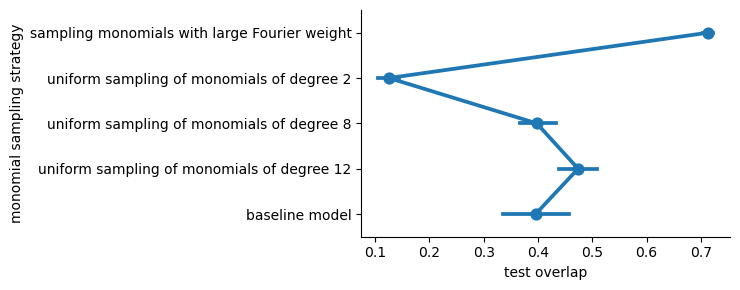

In [65]:
def get_html(df):
    def int_ignore_error(x):
        try:
            return int(x)
        except ValueError:
            return x

    df = df.copy()
    # Find the max values for highlighting
    # max_overlap = df[("test overlap", "mean")].max()
    # max_accuracy = df[("test accuracy", "mean")].max()

    # Apply LaTeX bold formatting to max values
    # df[("test overlap", "mean")] = df[("test overlap", "mean")].apply(
    #     lambda x: f"<b>{{{x:.4f}}}</b>" if x == max_overlap else x
    # )
    # df[("test accuracy", "mean")] = df[("test accuracy", "mean")].apply(
    #     lambda x: f"\\textbf{{{x:.4f}}}" if x == max_accuracy else x
    # )

    df["parity degree"] = df["parity degree"].apply(int_ignore_error)
    df["sampling power"] = df["sampling power"].apply(int_ignore_error)
    # df["number of parity inputs"] = df["number of parity inputs"].apply(int_ignore_error)
    df.rename(
        columns={
            "number of parity inputs": "\\# monomials",
            "parity degree": "monomial degree",
            # "sampling power": "power",
            # "parity degree": "degree",
        },
        inplace=True,
    )
    df["monomial sampling strategy"] = None
    for i, row in df.iterrows():
        if row["monomial degree"]:
            df.loc[
                i, "monomial sampling strategy"
            ] = f'uniform sampling of monomials of degree {row["monomial degree"]}'
        elif row["sampling power"]:
            df.loc[
                i, "monomial sampling strategy"
            ] = f"sampling monomials with large Fourier weight"
        else:
            df.loc[i, "monomial sampling strategy"] = "baseline model"
    df = df[["monomial sampling strategy", "test overlap"]]
    # Convert DataFrame to LaTeX
    return df
    # latex_table = df.to_html(index=False, escape=False, float_format="{:.4f}".format)
    # return latex_table


selected_columns = ["sampling power", "parity degree"]
df_selection = (
    df.query(
        'lattice == "kagome2x4" '
        "and J2 == 1 "
        "and epoch == 299 "
        "and sampling_power_train == 2 "
        "and eps_train == 0.01"
        "and (n_xors.isna() or n_xors == 8)"
        "and (xor_sampling_power.isna() or xor_sampling_power == 8)"
    )
    .rename(
        columns={
            "xor_hamming_weight": "parity degree",
            "xor_sampling_power": "sampling power",
            "n_xors": "number of parity inputs",
            "test_overlap": "test overlap",
            "test_accuracy": "test accuracy",
        }
    )
    # .groupby(selected_columns, dropna=False)[["test overlap"]]
    # .agg(["mean", "sem"])
    .reset_index()
    .fillna({"number of parity inputs": 0})
    .fillna("")
    .sort_values(selected_columns)
    .reset_index(drop=True)
)

sns.catplot(
    get_html(df_selection),
    y="monomial sampling strategy",
    x="test overlap",
    kind="point", aspect=2.5, height=3, linestyle="none"
)

In [23]:
df_selection

parity degree sampling power test overlap          
                                       mean       sem
0           2.0                    0.125488  0.010774
1           8.0                    0.397581  0.017441
2          12.0                    0.473768  0.019331
3                          8.0     0.713424  0.005231
4                                  0.395434  0.033821